In [249]:
import pyurg
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as la
import time
from pprint import pprint
import json
from scipy.stats import linregress
from sklearn.linear_model import RANSACRegressor, LinearRegression

urg = pyurg.UrgDevice()
if not urg.connect():
    print('Could not connect.')

Could not connect.


In [250]:
# datas = {}
# for i in range(1,5):
#     with open(f"measures/mesure_{i}.json") as f:
#         datas[i-1] = np.array(json.load(f))

In [251]:
# datas, timestamp = urg.capture()

In [252]:
# angles = []
# for i in range(len(datas)):
#     angles.append(urg.index2rad(i))

In [253]:
#Filter points by distance, and by angle, returns np vector
def filter_points(dist, angle, verbose):
    max_distance = 1000
    min_distance = 150
    # min_angle = np.pi/2
    min_angle = 0
    max_angle = np.pi/2
    if verbose:print(f"Filtering points by : (max_d:{max_distance}, min_d:{min_distance}, max_a:{max_angle}, min_a:{min_angle})")
    vector = np.array(list(zip(dist, angle)))
    vector = vector[np.logical_and(vector[:, 0] > min_distance, vector[:, 0] < max_distance)]  # Filter out data points with distance less than 1000
    vector = vector[np.logical_and(vector[:, 1] > min_angle, vector[:, 1] < max_angle)] #Filtrer la moitié des points
    return vector

#remove outliers points and transform polar values to cartesian, return np coords vector 
def remove_outliers_2cart(vector, verbose):
    x = vector[:, 0] * np.cos(vector[:, 1])
    y = vector[:, 0] * np.sin(vector[:, 1])
    dist_min = 6
    coords = []
    for i in range(0,len(vector[:,0])-2):
        p1 = np.array([x[i], y[i]])
        p2 = np.array([x[i+1], y[i+1]])
        p3 = np.array([x[i+2], y[i+2]])
        
        if la.norm(p1-p3) < dist_min:
            if la.norm(p2-p3) <= dist_min or la.norm(p1-p2) <= dist_min:
                coords.append([x[i], y[i]])
            else:
                if verbose:print(f"Pt abberant : ({x[i]};{y[i]})")
        else:
            coords.append([x[i], y[i]])
    return np.array(coords)

#plot points and center points
def plot_points(coords):
    plt.scatter(coords[:,0], coords[:,1], marker="+")
    plt.scatter(0,0)

#cluster points according to distance and alignment, returns cluster dict
def cluster_points(coords, corner_limit, verbose):
    d_max = 10
    clusters = {}
    curr_cluster = 0
    min_cluster_size = 10
    max_error_reg =30

    for i in range(0,len(coords[:,0])-1):
        if i==0:
            clusters[curr_cluster] = []
            clusters[curr_cluster].append(coords[i,:])

        elif la.norm(coords[i,:]-coords[i-1,:]) <= d_max:
            #look if distance between 2 points is under d_max
            
            if len(clusters[curr_cluster]) >= 5:
                reg = linregress(np.array(clusters[curr_cluster])[:,0], np.array(clusters[curr_cluster])[:,1])
                err = abs(reg.slope*coords[i,0] + reg.intercept - coords[i,1])
                if err < max_error_reg:
                    clusters[curr_cluster].append(coords[i,:])
                else:
                    print("Point trop éloigné de la régression linéaire.")
                    if (len(clusters[curr_cluster]) > min_cluster_size):
                        curr_cluster += 1
                        if verbose:
                            print(f"New cluster : {coords[i,:]}")
                    clusters[curr_cluster] = []
                    clusters[curr_cluster].append(coords[i,:])
            else:
                clusters[curr_cluster].append(coords[i,:])
        else:
            print("Point trop éloigné")
            if (len(clusters[curr_cluster]) > min_cluster_size):
                curr_cluster += 1
                if verbose:
                    print(f"New cluster : {coords[i,:]}")
            clusters[curr_cluster] = []
            clusters[curr_cluster].append(coords[i,:])

    # ----- Keeping only 2 main clusters
    if corner_limit:
        if len(clusters) > 2:
            if verbose: print(f"Too much clusters : {len(clusters)}")
            sorted_cluster_keys = sorted(clusters, key=lambda k: len(clusters[k]), reverse=True)
            clusters = {0: clusters[sorted_cluster_keys[0]], 1:clusters[sorted_cluster_keys[1]]}
    # -----
    return clusters

#Plot clusters
def plot_clusters(clusters):
    for cluster in clusters.values():
        print("Printing cluster")
        cluster = np.array(cluster)
        plt.plot(cluster[:,0], cluster[:,1], marker="+")

In [254]:
# ──────────────────────────────────────────────
# Variante 2 : Split-and-Merge + Merge colinéaire
# ──────────────────────────────────────────────
# Après le split, on tente de re-fusionner les segments adjacents
# qui sont colinéaires (même direction + faible distance entre droites).
# Robuste aux obstacles ponctuels devant un mur : le mur sera splitté
# en deux fragments, mais le merge les réunira si leur droite combinée
# reste cohérente.
# ──────────────────────────────────────────────


def _max_deviation_index(points):
    """
    Retourne l'index et la valeur du point le plus éloigné
    de la droite P0→Pn.
    """
    pts = np.array(points)
    p0, pn = pts[0], pts[-1]
    direction = pn - p0
    norm = la.norm(direction)
    if norm < 1e-9:
        return 0, 0.0
    dists = np.abs(np.cross(direction, pts - p0)) / norm
    idx = int(np.argmax(dists))
    return idx, dists[idx]

def _split(points, max_error):
    """
    Récursion Split : retourne une liste de listes de points.
    """
    if len(points) < 2:
        return [points]

    idx, dev = _max_deviation_index(points)

    if dev > max_error:
        left  = _split(points[:idx + 1], max_error)
        right = _split(points[idx:],     max_error)
        return left + right
    else:
        return [points]

def _segment_direction(points):
    """
    Retourne le vecteur directeur unitaire d'un segment (PCA sur 2D).
    Plus robuste que P0→Pn pour les segments bruités.
    """
    pts = np.array(points)
    centered = pts - pts.mean(axis=0)
    _, _, vt = np.linalg.svd(centered)
    return vt[0]  # premier vecteur propre = direction principale

def _angle_between(v1, v2):
    """Angle en degrés entre deux vecteurs directeurs (0-90°)."""
    cos_a = np.clip(np.abs(np.dot(v1, v2)), 0.0, 1.0)
    return np.degrees(np.arccos(cos_a))

def _mean_perp_distance(pts_a, pts_b, direction):
    """
    Distance perpendiculaire moyenne entre les deux nuages de points
    par rapport à une direction commune.
    Mesure si deux segments sont sur la même droite ou parallèles décalés.
    """
    all_pts = np.vstack([np.array(pts_a), np.array(pts_b)])
    centroid = all_pts.mean(axis=0)
    normal = np.array([-direction[1], direction[0]])  # perpendiculaire à la direction

    proj_a = [np.dot(np.array(p) - centroid, normal) for p in pts_a]
    proj_b = [np.dot(np.array(p) - centroid, normal) for p in pts_b]

    return abs(np.mean(proj_a) - np.mean(proj_b))

def _are_collinear(seg_a, seg_b,
                   max_angle_deg=10.0,
                   max_perp_dist=20.0,
                   max_gap=50.0):
    """
    Deux segments sont colinéaires si :
      1. Leurs directions sont proches (angle < max_angle_deg)
      2. Leur décalage perpendiculaire est faible (< max_perp_dist)
      3. Le gap spatial entre eux n'est pas trop grand (< max_gap)
         → évite de fusionner deux murs parallèles éloignés
    """
    if len(seg_a) < 2 or len(seg_b) < 2:
        return False

    dir_a = _segment_direction(seg_a)
    dir_b = _segment_direction(seg_b)

    # Critère 1 : directions similaires
    if _angle_between(dir_a, dir_b) > max_angle_deg:
        return False

    # Direction commune = moyenne des deux
    dir_common = (dir_a + dir_b) / 2
    dir_common /= la.norm(dir_common)

    # Critère 2 : pas de décalage latéral entre les deux droites
    if _mean_perp_distance(seg_a, seg_b, dir_common) > max_perp_dist:
        return False

    # Critère 3 : gap spatial raisonnable (dernier point de A, premier de B)
    gap = la.norm(np.array(seg_a[-1]) - np.array(seg_b[0]))
    if gap > max_gap:
        return False

    return True

def _merge_pass(segments, max_angle_deg, max_perp_dist, max_gap):
    """
    Un passage de fusion : parcourt les segments et fusionne
    les voisins colinéaires. Retourne la nouvelle liste et un flag
    indiquant si au moins une fusion a eu lieu (pour itérer).
    """
    merged = []
    i = 0
    changed = False

    while i < len(segments):
        if i + 1 < len(segments) and _are_collinear(
                segments[i], segments[i + 1],
                max_angle_deg, max_perp_dist, max_gap):
            # Fusion : on concatène les deux segments
            merged.append(segments[i] + segments[i + 1])
            i += 2
            changed = True
        else:
            merged.append(segments[i])
            i += 1

    return merged, changed

def cluster_points_collinear(coords, corner_limit=True, verbose=False,
                              d_max=10, min_cluster_size=10,
                              max_split_error=20,
                              max_angle_deg=10.0,
                              max_perp_dist=20.0,
                              max_gap=50.0):
    """
    Pipeline :
      1. Pré-segmentation par saut de distance (ruptures évidentes)
      2. Split-and-Merge sur chaque pré-segment
      3. Merge itératif des segments colinéaires adjacents
         → réunit les fragments du même mur séparés par un obstacle
      4. Filtrage par taille minimale
    """
    # ── Étape 1 : pré-segmentation par distance ──────────────────────
    raw_segments = []
    current = [coords[0]]

    for i in range(1, len(coords)):
        if la.norm(coords[i] - coords[i - 1]) <= d_max:
            current.append(coords[i])
        else:
            if verbose:
                print(f"Rupture distance à l'index {i}")
            raw_segments.append(current)
            current = [coords[i]]
    raw_segments.append(current)

    # ── Étape 2 : Split ───────────────────────────────────────────────
    split_segments = []
    for seg in raw_segments:
        parts = _split(seg, max_split_error)
        if verbose and len(parts) > 1:
            print(f"Segment splitté en {len(parts)} parties")
        split_segments.extend(parts)

    # ── Étape 3 : Merge colinéaire itératif ──────────────────────────
    # On itère jusqu'à stabilité (au cas où 3 fragments du même mur)
    segments = split_segments
    for _ in range(10):  # max 10 passes, converge en général en 2-3
        segments, changed = _merge_pass(segments, max_angle_deg,
                                        max_perp_dist, max_gap)
        if not changed:
            break

    if verbose:
        print(f"Segments après merge : {len(segments)}")

    # ── Étape 4 : filtrage taille + numérotation ──────────────────────
    clusters = {}
    idx = 0
    for seg in segments:
        if len(seg) >= min_cluster_size:
            clusters[idx] = [np.array(p) for p in seg]
            idx += 1

    # ── Optionnel : garder les 2 plus grands clusters ─────────────────
    if corner_limit and len(clusters) > 2:
        if verbose:
            print(f"Trop de clusters : {len(clusters)}, on garde les 2 plus grands")
        sorted_keys = sorted(clusters, key=lambda k: len(clusters[k]), reverse=True)
        clusters = {0: clusters[sorted_keys[0]], 1: clusters[sorted_keys[1]]}

    return clusters

In [255]:

 
def detect_line1(cluster):
    ransac = RANSACRegressor(
    #    residual_threshold=10,  # Très strict : 1cm de tolérance max
    # min_samples=2,            # On utilise le strict minimum pour définir une ligne
    # max_trials=1000,          # On lui donne plus de chances de réussir
        stop_probability=0.99     # On s'assure d'une haute confiance statistique
    )
    ransac.fit(cluster[:,0].reshape(-1, 1),cluster[:,1])
    return ransac.estimator_

def detect_line2(cluster, verbose):
    model = LinearRegression()
    model.fit(cluster[:,0].reshape(-1, 1),cluster[:,1])
    if (verbose):print(model.coef_)
    return model

def detect_intersection(line1_model, line2_model, verbose):
    a1, b1 = line1_model.coef_[0], line1_model.intercept_
    a2, b2 = line2_model.coef_[0], line2_model.intercept_

    x_corner = (b2 - b1) / (a1 - a2)
    y_corner = a1 * x_corner + b1
    if (verbose):print(f"Coin détecté en : ({x_corner:.3f}, {y_corner:.3f})")
    return np.array([x_corner, y_corner])

In [256]:
def plot_lidar_detection(points, line1_model, line2_model, corner):
    plt.figure()
    
    # 1. Afficher tous les points (en gris léger pour le fond)
    plt.scatter(points[:, 0], points[:, 1], c='lightgrey', label='Tous les points', marker="+")
    
    # 3. Tracer les lignes de régression
    # On définit une plage de X pour tracer la ligne
    x_range = np.linspace(points[:, 0].min(), points[:, 0].max(), 100).reshape(-1, 1)
    
    y1_plot = line1_model.predict(x_range)
    y2_plot = line2_model.predict(x_range)
    
    plt.plot(x_range, y1_plot, 'b--', alpha=0.6, label='Modèle Ligne 1')
    plt.plot(x_range, y2_plot, 'r--', alpha=0.6, label='Modèle Ligne 2')
    
    # 4. Afficher le coin (l'intersection)
    plt.scatter(corner[0], corner[1], c='yellow', edgecolors='black', 
                s=100, marker='*', label='Coin détecté', zorder=5)
    
    plt.xlabel('X (mètres)')
    plt.ylabel('Y (mètres)')
    plt.title('Détection de coin sur nuage de points LIDAR 2D')
    plt.legend()
    plt.axis('equal') # Important pour ne pas déformer la géométrie
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [257]:
def detect_rotation(line1_model, line2_model):
    pente1 = line1_model.coef_[0]
    pente2 = line2_model.coef_[0]

    angle1 = np.degrees(np.arctan(pente1))
    angle2 = np.degrees(np.arctan(pente2))
    err = abs(angle1 - angle2) -90
    print(f"Erreur d'angle entre les deux droites : {err}")
    biss = (angle1 + angle2)/2
    theta = biss-45
    print(f"Correction : {-theta}")
    correction = - np.deg2rad(theta)

In [269]:
def compute_offset(data, verbose):
    angles = []
    for i in range(0,len(data)):
        angles.append(urg.index2rad(i))
    vector = filter_points(data, angles, verbose)
    coords = remove_outliers_2cart(vector, verbose)
    # plot_points(coords)


    # clusters = cluster_points(coords, True, verbose)
    clusters = cluster_points_collinear(coords, verbose=True)
    plot_clusters(clusters)


    
    line1_model = detect_line2(np.array(clusters[0][:]), verbose)
    line2_model = detect_line2(np.array(clusters[1][:]), verbose)
    angle = detect_rotation(line1_model, line2_model)

    intersection = detect_intersection(line1_model, line2_model, verbose)
    if verbose: plot_lidar_detection(coords, line1_model, line2_model, intersection)

    correction = {
        "angle": angle,
        "point": intersection,
    }

    return correction

In [259]:
# for data in datas.values():
#     point = compute_offset(data, False)
#     print(point)

In [260]:
with open(f"measures/mesure_lol1.json") as f:
    datas = np.array(json.load(f))

Filtering points by : (max_d:1000, min_d:150, max_a:1.5707963267948966, min_a:0)
Rupture distance à l'index 23
Rupture distance à l'index 24
Rupture distance à l'index 27
Rupture distance à l'index 132
Rupture distance à l'index 133
Rupture distance à l'index 134
Segments après merge : 7
Printing cluster
Printing cluster
[1.21974634]
[-1.17012346]
Erreur d'angle entre les deux droites : 10.136086875294282
Correction : 44.41440289578406
Coin détecté en : (387.715, 69.366)


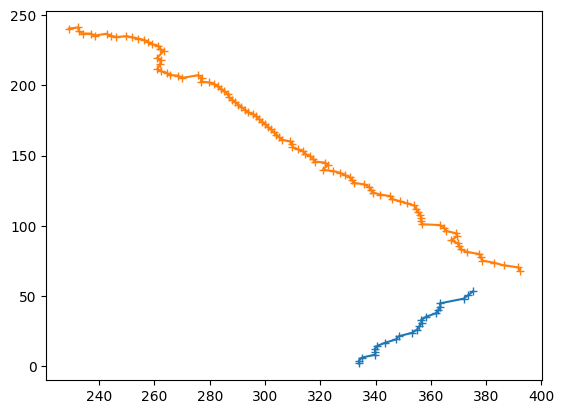

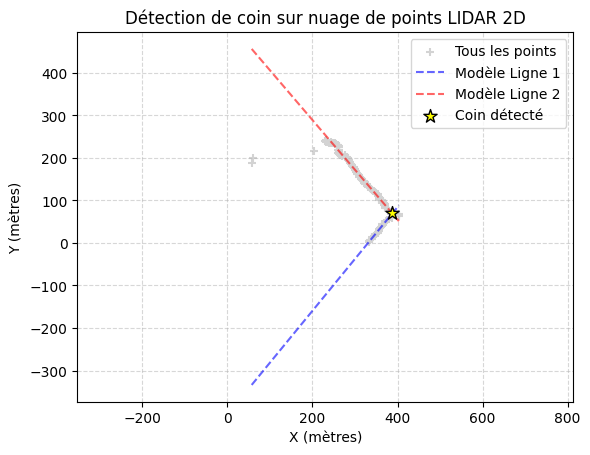

[387.71509275  69.36625472]


In [271]:
correction = compute_offset(datas, True)
print(correction["point"])